<a href="https://colab.research.google.com/github/karmagodjs/ai-ml-projects-small/blob/main/student_score_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Step 1: Libraries Import

In [8]:
import pandas as pd  # data handling
import numpy as np  # numerical operations
import matplotlib.pyplot as plt  # plotting
import seaborn as sns  # better visualizations
from sklearn.model_selection import train_test_split  # data spli
from sklearn.preprocessing import StandardScaler  # scaling
from sklearn.linear_model import LinearRegression, Ridge, Lasso  # linear models
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor  # tree based models
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score  # evaluation metrics
import joblib  # model save/load ke liye
import os  # folder banane create
import warnings  # warnings handle
warnings.filterwarnings("ignore")  # unnecessary warnings ignore

## Step 2: Data Load Karna
`StudentsPerformance.csv` ko `data/` folder mein rakho (Kaggle se download karke).

In [9]:
df = pd.read_csv("Students_Performance.csv")  # dataset load

print("Shape:", df.shape)  # (rows, columns) - like (1000, 8)
df.head()  # pehli 5 rows show

Shape: (145, 15)


,Student_ID,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Weekly_Study_Hours,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade
0,STUDENT1,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,Yes,No,No,AA
1,STUDENT2,19-22,Male,Other,50%,Yes,No,Private,0,Always,Yes,No,Yes,Yes,AA
2,STUDENT3,19-22,Male,State,50%,No,No,Private,2,Never,No,No,No,Yes,AA
3,STUDENT4,18,Female,Private,50%,Yes,No,Bus,2,Always,No,Yes,No,No,AA
4,STUDENT5,19-22,Male,Private,50%,No,No,Bus,12,Always,Yes,No,Yes,Yes,AA


## Step 3: Basic Exploration (EDA)

In [10]:
df.info()  # column types aur non-null counts - is dataset mein usually koi missing value nahi hoti

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 145 entries, 0 to 144
Data columns (total 15 columns):
 #   Column              Non-Null Count  Dtype 
---  ------              --------------  ----- 
 0   Student_ID          145 non-null    object
 1   Student_Age         145 non-null    object
 2   Sex                 145 non-null    object
 3   High_School_Type    145 non-null    object
 4   Scholarship         144 non-null    object
 5   Additional_Work     145 non-null    object
 6   Sports_activity     145 non-null    object
 7   Transportation      145 non-null    object
 8   Weekly_Study_Hours  145 non-null    int64 
 9   Attendance          145 non-null    object
 10  Reading             145 non-null    object
 11  Notes               145 non-null    object
 12  Listening_in_Class  145 non-null    object
 13  Project_work        145 non-null    object
 14  Grade               145 non-null    object
dtypes: int64(1), object(14)
memory usage: 17.1+ KB


In [11]:
df.describe()  # numeric columns (math, reading, writing scores) ka statistical summary

,Weekly_Study_Hours
count,145.000000
mean,2.331034
std,4.249273
min,0.000000
25%,0.000000
50%,0.000000
75%,2.000000
max,12.000000


In [12]:
df.isnull().sum()  # missing values check kar rahe - agar sab 0 hai to cleaning ki zaroorat kam hai

,0
Student_ID,0
Student_Age,0
Sex,0
High_School_Type,0
Scholarship,1
Additional_Work,0
Sports_activity,0
Transportation,0
Weekly_Study_Hours,0
Attendance,0


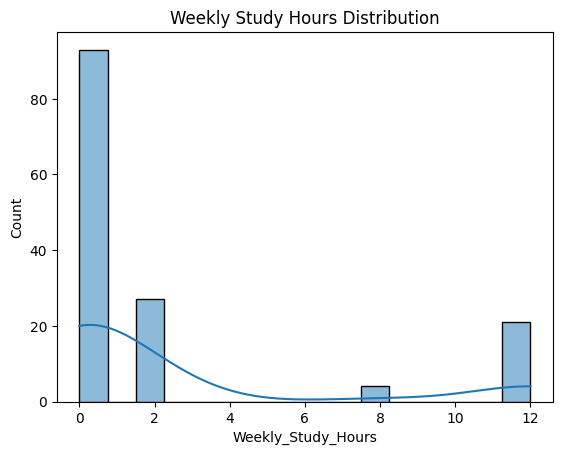

In [15]:
sns.histplot(df["Weekly_Study_Hours"], kde=True)  # Weekly_Study_Hours distribution
plt.title("Weekly Study Hours Distribution")
plt.show()  #curve dikhega

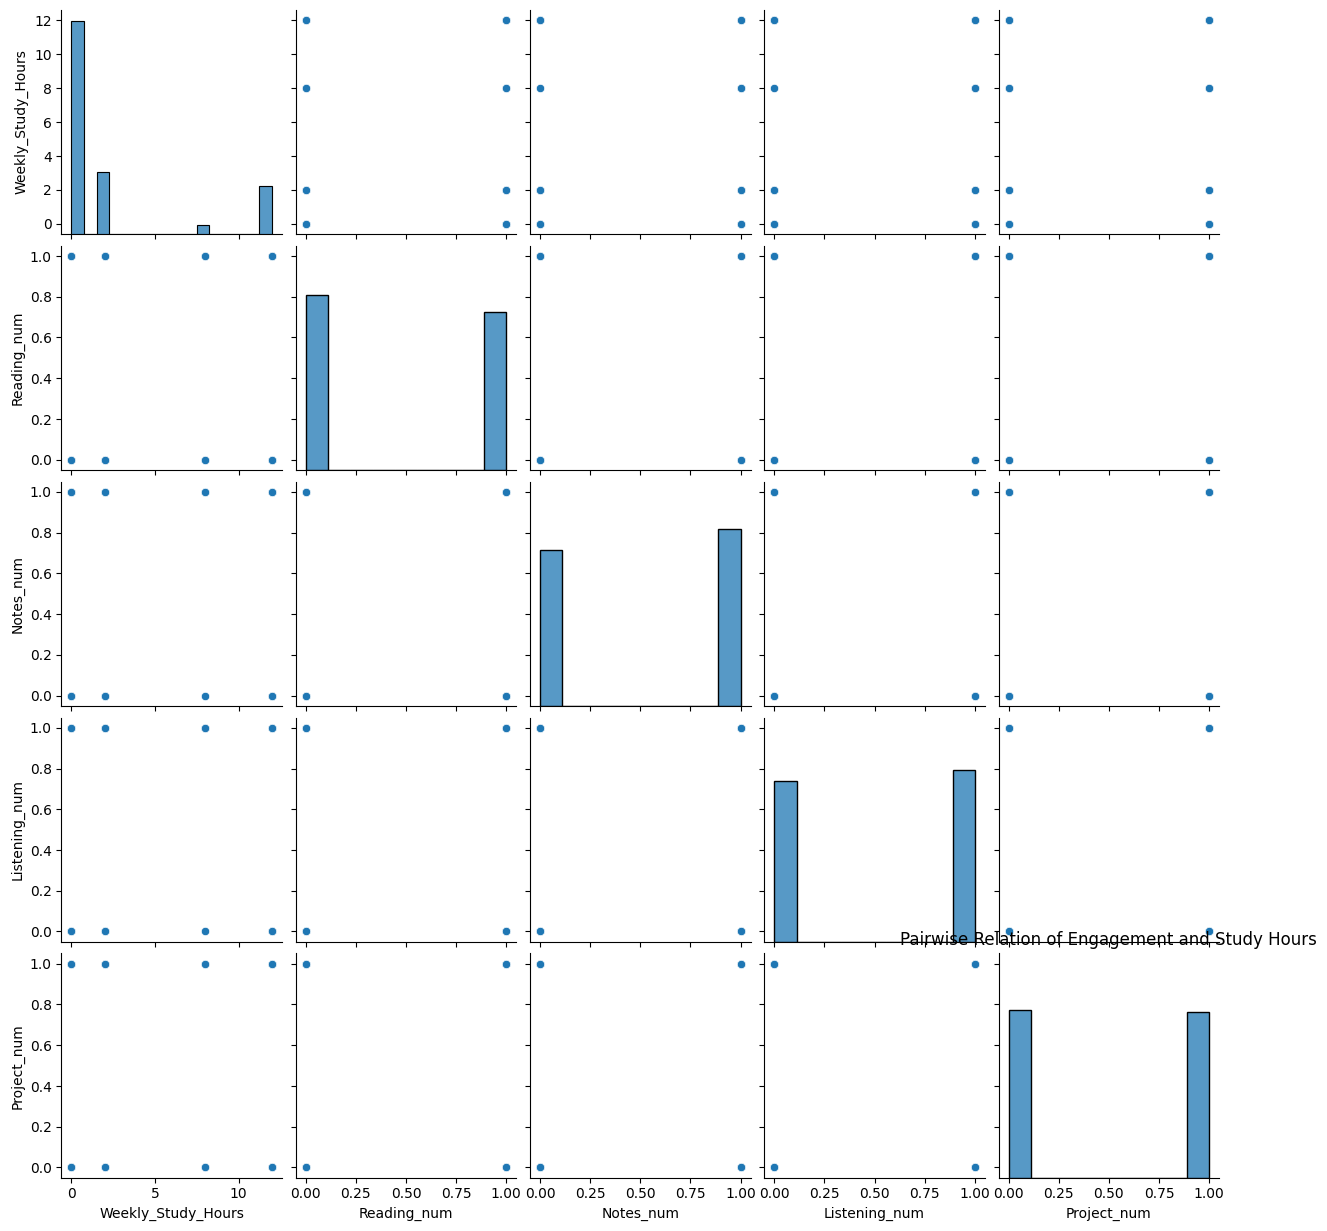

In [17]:
# The original 'math score', 'reading score', 'writing score' columns are not present in the loaded dataset.
# Converting relevant 'Yes'/'No' columns to numerical (1/0) and using 'Weekly_Study_Hours' as proxies for a pairplot.
df['Reading_num'] = (df['Reading'] == 'Yes').astype(int)
df['Notes_num'] = (df['Notes'] == 'Yes').astype(int)
df['Listening_num'] = (df['Listening_in_Class'] == 'Yes').astype(int)
df['Project_num'] = (df['Project_work'] == 'Yes').astype(int)

sns.pairplot(df[["Weekly_Study_Hours", "Reading_num", "Notes_num", "Listening_num", "Project_num"]])
plt.title("Pairwise Relation of Engagement and Study Hours")
plt.show()  # Displaying relations between available numerical/binary features

## Step 4: Target Variable Decide Karna


In [19]:
target_col = "Weekly_Study_Hours"  # Weekly_Study_Hours target predict
y = df[target_col]  # target find
X = df.drop(columns=[target_col])  # columns features honge

X.head()  # features show 5 rows dikhega

,Student_ID,Student_Age,Sex,High_School_Type,Scholarship,Additional_Work,Sports_activity,Transportation,Attendance,Reading,Notes,Listening_in_Class,Project_work,Grade,Reading_num,Notes_num,Listening_num,Project_num
0,STUDENT1,19-22,Male,Other,50%,Yes,No,Private,Always,Yes,Yes,No,No,AA,1,1,0,0
1,STUDENT2,19-22,Male,Other,50%,Yes,No,Private,Always,Yes,No,Yes,Yes,AA,1,0,1,1
2,STUDENT3,19-22,Male,State,50%,No,No,Private,Never,No,No,No,Yes,AA,0,0,0,1
3,STUDENT4,18,Female,Private,50%,Yes,No,Bus,Always,No,Yes,No,No,AA,0,1,0,0
4,STUDENT5,19-22,Male,Private,50%,No,No,Bus,Always,Yes,No,Yes,Yes,AA,1,0,1,1


## Step 5: Data Cleaning

In [20]:
print("Missing values:\n", X.isnull().sum())  # is dataset mein generally 0 missing values hote hain
# Agar kabhi missing mile to categorical ko mode se, numeric ko median se fill karo (jaisa pichle project mein kiya)

Missing values:
 Student_ID            0
Student_Age           0
Sex                   0
High_School_Type      0
Scholarship           1
Additional_Work       0
Sports_activity       0
Transportation        0
Attendance            0
Reading               0
Notes                 0
Listening_in_Class    0
Project_work          0
Grade                 0
Reading_num           0
Notes_num             0
Listening_num         0
Project_num           0
dtype: int64


## Step 6: Feature Engineering


In [22]:
X["avg_engagement_activities"] = (X["Reading_num"] + X["Notes_num"] + X["Listening_num"]) / 3  # new average engagement feature
X["additional_work_flag"] = (X["Additional_Work"] == "Yes").astype(int)  # 0/1 flag for additional work
X["sports_activity_flag"] = (X["Sports_activity"] == "Yes").astype(int)  # 0/1 flag for sports activity

X[["avg_engagement_activities", "additional_work_flag", "sports_activity_flag"]].head()  # checking new features

,avg_engagement_activities,additional_work_flag,sports_activity_flag
0,0.666667,1,0
1,0.666667,1,0
2,0.000000,0,0
3,0.333333,1,0
4,0.666667,0,0


## Step 7: Encoding Categorical Variables


In [24]:
# Drop Student_ID as it's an identifier and not useful for modeling.
X = X.drop(columns=['Student_ID'])

# Drop original 'Yes'/'No' columns as their numerical flags have already been created.
X = X.drop(columns=['Additional_Work', 'Sports_activity', 'Reading', 'Notes', 'Listening_in_Class', 'Project_work'])

# Identify remaining categorical columns for one-hot encoding
categorical_cols = ['Student_Age', 'Sex', 'High_School_Type', 'Scholarship', 'Transportation', 'Attendance', 'Grade']

X = pd.get_dummies(X, columns=categorical_cols, drop_first=True)
# drop_first=True redundant column hatata hai (dummy variable trap se bachne ke liye)

X.shape  # ab columns badh gaye honge categorical encoding ki wajah se

(145, 26)

In [25]:
X.head()  # final feature set - binary columns

,Reading_num,Notes_num,Listening_num,Project_num,avg_engagement_activities,additional_work_flag,sports_activity_flag,Student_Age_19-22,Student_Age_23-27,Sex_Male,...,Attendance_Always,Attendance_Never,Attendance_Sometimes,Grade_BA,Grade_BB,Grade_CB,Grade_CC,Grade_DC,Grade_DD,Grade_Fail
0,1,1,0,0,0.666667,1,0,True,False,True,...,True,False,False,False,False,False,False,False,False,False
1,1,0,1,1,0.666667,1,0,True,False,True,...,True,False,False,False,False,False,False,False,False,False
2,0,0,0,1,0.000000,0,0,True,False,True,...,False,True,False,False,False,False,False,False,False,False
3,0,1,0,0,0.333333,1,0,False,False,False,...,True,False,False,False,False,False,False,False,False,False
4,1,0,1,1,0.666667,0,0,True,False,True,...,True,False,False,False,False,False,False,False,False,False


## Step 8: Train-Validation Split

In [26]:
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)
# 80% training, 20% validation, random_state fix taaki reproducible rahe

print("X_train shape:", X_train.shape)
print("X_val shape:", X_val.shape)

X_train shape: (116, 26)
X_val shape: (29, 26)


## Step 9: Feature Scaling

In [27]:
scaler = StandardScaler()  # mean=0, std=1
X_train_scaled = scaler.fit_transform(X_train)  # train pe fit + transform
X_val_scaled = scaler.transform(X_val)  # val ko sirf transform (data leakage avoid karne ke liye)

X_train_scaled[:5]  # scaled values dikhega, -3 se +3 ke range mein

array([[-0.96609178,  0.98290472, -1.07151675, -1.        , -0.60061368,
        -0.68436425, -0.81064348,  1.        , -0.23354968, -1.30294836,
        -0.4       ,  0.57735027, -0.13245324,  0.93325653, -0.60390884,
        -1.19023807, -1.4327008 ,  2.25948294, -0.44257913, -0.45643546,
        -0.38537625, -0.25341701, -0.37047929, -0.29002095, -0.38537625,
         5.29150262],
       [ 1.03509834, -1.01739261,  0.93325653,  1.        ,  0.54153692,
        -0.68436425, -0.81064348,  1.        , -0.23354968,  0.76749013,
         2.5       , -1.73205081, -0.13245324,  0.93325653, -0.60390884,
        -1.19023807,  0.69798244, -0.44257913, -0.44257913, -0.45643546,
        -0.38537625, -0.25341701, -0.37047929, -0.29002095, -0.38537625,
        -0.18898224],
       [ 1.03509834,  0.98290472, -1.07151675, -1.        ,  0.54153692,
        -0.68436425,  1.23358791,  1.        , -0.23354968,  0.76749013,
        -0.4       ,  0.57735027, -0.13245324,  0.93325653, -0.60390884,
       

## Step 10: Model Training Function

In [28]:
def evaluate_model(model, X_tr, y_tr, X_v, y_v, name):
    model.fit(X_tr, y_tr)  # model train kar rahe
    preds = model.predict(X_v)  # validation pe predict
    rmse = np.sqrt(mean_squared_error(y_v, preds))  # RMSE
    mae = mean_absolute_error(y_v, preds)  # MAE
    r2 = r2_score(y_v, preds)  # R-squared
    print(f"{name} -> RMSE: {rmse:.4f}, MAE: {mae:.4f}, R2: {r2:.4f}")
    return model, rmse

## Step 11: Multiple Models Train Karna

In [29]:
results = {}  # sab models ke RMSE store karne ke liye

lr = LinearRegression()
model_lr, rmse_lr = evaluate_model(lr, X_train_scaled, y_train, X_val_scaled, y_val, "Linear Regression")
results["Linear Regression"] = rmse_lr

Linear Regression -> RMSE: 4.8827, MAE: 4.0094, R2: -0.2274


In [30]:
ridge = Ridge(alpha=1.0)
model_ridge, rmse_ridge = evaluate_model(ridge, X_train_scaled, y_train, X_val_scaled, y_val, "Ridge Regression")
results["Ridge Regression"] = rmse_ridge

Ridge Regression -> RMSE: 4.8621, MAE: 3.9925, R2: -0.2170


In [31]:
lasso = Lasso(alpha=0.01)
model_lasso, rmse_lasso = evaluate_model(lasso, X_train_scaled, y_train, X_val_scaled, y_val, "Lasso Regression")
results["Lasso Regression"] = rmse_lasso

Lasso Regression -> RMSE: 4.8432, MAE: 3.9691, R2: -0.2076


In [32]:
rf = RandomForestRegressor(n_estimators=300, max_depth=8, random_state=42, n_jobs=-1)
model_rf, rmse_rf = evaluate_model(rf, X_train, y_train, X_val, y_val, "Random Forest")
# Note: trees ko scaling ki zaroorat nahi
results["Random Forest"] = rmse_rf

Random Forest -> RMSE: 4.6565, MAE: 3.7032, R2: -0.1163


In [33]:
gbr = GradientBoostingRegressor(n_estimators=300, learning_rate=0.05, max_depth=3, random_state=42)
model_gbr, rmse_gbr = evaluate_model(gbr, X_train, y_train, X_val, y_val, "Gradient Boosting")
results["Gradient Boosting"] = rmse_gbr

Gradient Boosting -> RMSE: 5.8838, MAE: 4.2664, R2: -0.7823


## Step 12: Best Model Select Karna

Best Model: Random Forest with RMSE: 4.6565


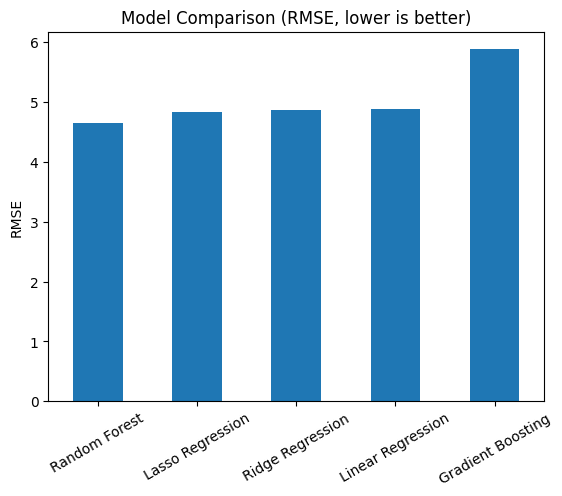

In [34]:
best_model_name = min(results, key=results.get)  # sabse kam RMSE best hai
print(f"Best Model: {best_model_name} with RMSE: {results[best_model_name]:.4f}")

pd.Series(results).sort_values().plot(kind="bar", title="Model Comparison (RMSE, lower is better)")
plt.ylabel("RMSE")
plt.xticks(rotation=30)
plt.show()  # bar chart mein sab models compare honge

In [42]:
best_model = model_rf # From previous cell's execution

y_pred_best = best_model.predict(X_val) # Random Forest was trained on unscaled X_val

# Calculate regression metrics
rmse_best = np.sqrt(mean_squared_error(y_val, y_pred_best))
mae_best = mean_absolute_error(y_val, y_pred_best)
r2_best = r2_score(y_val, y_pred_best)

print(f"Best Model ({best_model_name}) Performance:")
print(f"RMSE: {rmse_best:.4f}")
print(f"MAE: {mae_best:.4f}")
print(f"R2 Score: {r2_best:.4f}")

Best Model (Random Forest) Performance:
RMSE: 4.6565
MAE: 3.7032
R2 Score: -0.1163


## Step 13: Feature Importance (Random Forest se)

In [35]:
importances = pd.Series(model_rf.feature_importances_, index=X.columns)  # importance score
top_features = importances.sort_values(ascending=False).head(10)  # top 10

top_features  # Series print hoga - feature name and importance

,0
avg_engagement_activities,0.096938
Student_Age_23-27,0.081355
Grade_Fail,0.061666
Grade_BA,0.059704
High_School_Type_State,0.053584
High_School_Type_Private,0.052823
Listening_num,0.051755
Project_num,0.050820
sports_activity_flag,0.045916
Student_Age_19-22,0.044379


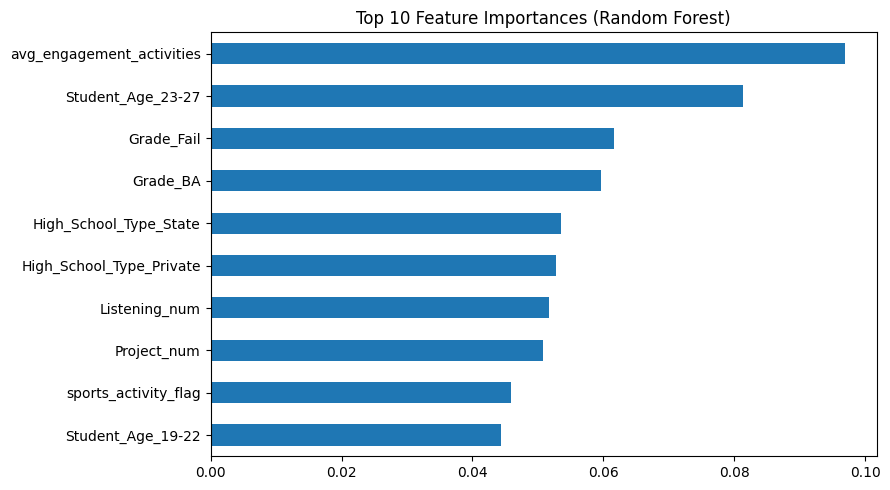

In [36]:
plt.figure(figsize=(9, 5))
top_features.plot(kind="barh")
plt.title("Top 10 Feature Importances (Random Forest)")
plt.gca().invert_yaxis()  # important upar
plt.tight_layout()
plt.show()  # avg_reading_writing sabse top pe hone ki umeed hai (obvious correlation)